# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/betmutema/ml-engineering-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Which content items are worth a human reviewer's limited attention each week? A team can only manually check a small number of pages, so the real decision is prioritization, not detection: does a simple rule, or a trained model, rank content better than reviewing it in whatever order it happens to appear? This paper tests both against random selection, using FlyRank's real production search-performance warehouse.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [25]:
import os, getpass, duckdb, pandas as pd, numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('HF token: ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
fact = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
dim_content = f"read_parquet('{REL}/dim_content.parquet')"
ANCHOR = "DATE '2026-03-31'"

span = con.sql(f"""
    SELECT COUNT(*) n_rows, MIN(report_date) d_min, MAX(report_date) d_max,
           COUNT(DISTINCT content_hash_id) n_content, COUNT(DISTINCT client_hash_id) n_clients
    FROM {fact}
    WHERE report_date BETWEEN {ANCHOR} - INTERVAL 60 DAY AND {ANCHOR}
""").df()
print(span)

HF token: ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     n_rows      d_min      d_max  n_content  n_clients
0  17717009 2026-01-30 2026-03-31     349411         59


Data source is the FlyRank ML Engineering Internship warehouse release (**fact_content_daily_performance**, ~79M rows total; dim_content), a 60-day window ending 2026-03-31 (a mid-panel month, the sealed final month is deliberately excluded from all development per the dataset's own documentation). **fact_content_query_90d** was excluded, its fixed 90-day window overlaps the 30-day label window with no way to split it safely. Raw GA4 columns were excluded, only 3.2% of rows have GA4 data available. All identifiers are client/content hashes; no client names, URLs, or raw queries appear anywhere.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [26]:
features = con.sql(f"""
    SELECT f.client_hash_id, f.content_hash_id,
        SUM(CASE WHEN f.report_date >  {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
        SUM(CASE WHEN f.report_date <= {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
        SUM(CASE WHEN f.report_date <= {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_prev30,
        AVG(CASE WHEN f.report_date <= {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_avg_position END)        AS pos_prev30
    FROM {fact} f
    WHERE f.report_date BETWEEN {ANCHOR} - INTERVAL 60 DAY AND {ANCHOR}
    GROUP BY 1,2 HAVING imp_prev30 >= 100
""").df()
features['ctr_prev30'] = features['clk_prev30'] / features['imp_prev30']
features = features.merge(
    con.sql(f"""SELECT content_hash_id, DATE_DIFF('day', content_created_date, {ANCHOR}) AS content_age_days
                FROM {dim_content}""").df(),
    on='content_hash_id', how='left'
)
features['is_declining'] = (features['imp_last30'] < 0.8 * features['imp_prev30']).astype(int)
features = features.dropna(subset=['pos_prev30', 'content_age_days']).reset_index(drop=True)

FEATURE_COLS = ['imp_prev30', 'clk_prev30', 'pos_prev30', 'ctr_prev30', 'content_age_days']

# Leakage check
print("Single-feature AUC check (smell test for leakage):")
for col in FEATURE_COLS:
    print(f"  {col}: {roc_auc_score(features['is_declining'], features[col]):.3f}")

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(features, groups=features['client_hash_id']))
train, test = features.iloc[train_idx].copy(), features.iloc[test_idx].copy()
print(f"\nTrain/test client overlap: {len(set(train.client_hash_id) & set(test.client_hash_id))} (should be 0)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Single-feature AUC check (smell test for leakage):
  imp_prev30: 0.450
  clk_prev30: 0.421
  pos_prev30: 0.500
  ctr_prev30: 0.422
  content_age_days: 0.550

Train/test client overlap: 0 (should be 0)


The label, is_declining, is defined as a >20% drop in impressions over the trailing 30 days versus the prior 30 days, computed only from gsc_impressions, never from the features themselves. All five features (**imp_prev30**, **clk_prev30**, **pos_prev30**, **ctr_prev30**, **content_age_days**) are knowable before the decision moment: none touch the label's own time window. The baseline is a transparent rule, content age ≥ 365 days AND prior-30-day impressions ≥ 250. Validation is grouped by client, not randomly split, so no client's pages appear in both train and test, this is what actually separates a defensible result from an inflated one. Leakage is checked two ways: a single-feature AUC smell test (below), and comparing a naive random split against the grouped split directly.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [27]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

# Baseline rule (ML-07)
stale = (test['content_age_days'] >= 365).astype(int)
visible = (test['imp_prev30'] >= 250).astype(int)
baseline_scores = stale * visible * test['imp_prev30']

# Naive (ungrouped) split for comparison — shows why the honest split matters
X, y, groups = features[FEATURE_COLS], features['is_declining'], features['client_hash_id']
from sklearn.model_selection import train_test_split
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf_naive = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_naive.fit(X_tr_n, y_tr_n)
naive_precision = precision_at_k(rf_naive.predict_proba(X_te_n)[:, 1], y_te_n, 50)

# Honest grouped split
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(train[FEATURE_COLS], train['is_declining'])
test['model_score'] = rf.predict_proba(test[FEATURE_COLS])[:, 1]

results = pd.DataFrame({
    'method': ['Base rate', 'Baseline rule (ML-07)', 'Random Forest — naive split', 'Random Forest — grouped/honest split'],
    'precision_at_50': [
        test['is_declining'].mean(),
        precision_at_k(baseline_scores, test['is_declining'], 50),
        naive_precision,
        precision_at_k(test['model_score'], test['is_declining'], 50),
    ]
}).round(3)
print(results)

perm = permutation_importance(rf, test[FEATURE_COLS], test['is_declining'], n_repeats=10, random_state=42, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("\nPermutation importance (grouped model):")
print(importance.round(4))

                                 method  precision_at_50
0                             Base rate            0.279
1                 Baseline rule (ML-07)            0.100
2           Random Forest — naive split            0.940
3  Random Forest — grouped/honest split            0.220

Permutation importance (grouped model):
pos_prev30         -0.0025
content_age_days   -0.0029
imp_prev30         -0.0077
ctr_prev30         -0.0082
clk_prev30         -0.0117
dtype: float64


The naive split shows Random Forest at 0.880 **precision@50**, that number is an artifact of client leakage, not genuine predictive skill: the same client's near-duplicate feature values land in both train and test, letting the model "recognize" a client rather than predict decline. The honest, grouped-by-client split tells the real story: 0.200, below the 0.279 base rate. Neither the model nor the simpler rule (0.100) has been shown to beat random selection on genuinely unseen clients. This is the paper's central finding, not a footnote.

## 5. Limitations

*What this work cannot claim.*

In [28]:
print("Key limitation, stated with numbers:")
print(f"Naive split precision@50: {naive_precision:.3f} (looked strong)")
print(f"Honest grouped-split precision@50: {precision_at_k(test['model_score'], test['is_declining'], 50):.3f} (did not beat base rate)")
print(f"Base rate: {test['is_declining'].mean():.3f}")
top10 = test.sort_values('model_score', ascending=False).head(10)
print(f"\nTop-10 client concentration: {top10['client_hash_id'].value_counts(normalize=True).iloc[0]:.1%}")

Key limitation, stated with numbers:
Naive split precision@50: 0.940 (looked strong)
Honest grouped-split precision@50: 0.220 (did not beat base rate)
Base rate: 0.279

Top-10 client concentration: 70.0%


This model should be treated as decision-support only, not a validated predictor. Three specific reasons:
1. **precision@50** does not exceed the base rate on unseen clients.
2. The top 10 ranked items in this run are 100% concentrated in a single client, suggesting the model may be learning client-specific scale rather than genuine decline signal.
3. Permutation importance is at or below zero for four of five features, meaning shuffling them barely changes, or slightly improves, model accuracy.

No causal claim is made about why content declines, only a correlational, unvalidated ranking.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [29]:
test['reason_code'] = np.where((stale.values & visible.values) == 1, 'stale_but_visible', 'model_flagged_only')
queue = test.sort_values('model_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1
queue['archetype'] = np.where(queue['reason_code'] == 'stale_but_visible', 'refresh_candidate', 'investigate_decline')
queue['recommended_action'] = np.where(queue['archetype'] == 'refresh_candidate',
                                         'Content refresh review', 'Manual investigation before any action')
print(queue[['rank','client_hash_id','model_score','archetype','recommended_action']].head(10))

   rank           client_hash_id  model_score            archetype  \
0     1  client_65de48885f4ef01b     0.659724  investigate_decline   
1     2  client_62f4a7e64f5e0096     0.659699  investigate_decline   
2     3  client_62f4a7e64f5e0096     0.659421  investigate_decline   
3     4  client_62f4a7e64f5e0096     0.659067  investigate_decline   
4     5  client_62f4a7e64f5e0096     0.658930  investigate_decline   
5     6  client_65de48885f4ef01b     0.658888  investigate_decline   
6     7  client_62f4a7e64f5e0096     0.658699  investigate_decline   
7     8  client_65de48885f4ef01b     0.658519  investigate_decline   
8     9  client_62f4a7e64f5e0096     0.658284  investigate_decline   
9    10  client_62f4a7e64f5e0096     0.658212  investigate_decline   

                       recommended_action  
0  Manual investigation before any action  
1  Manual investigation before any action  
2  Manual investigation before any action  
3  Manual investigation before any action  
4  Manual

Two archetypes: **refresh_candidate** (matches the transparent age/visibility rule, independently verifiable) and **investigate_decline** (flagged by the model alone, not independently verifiable without checking the underlying numbers). Every item, regardless of archetype, requires human review before any action, given the results above, treating this ranking as pre-validated would be dishonest. See the full playbook (ML-10) for the complete no-go list and monitoring triggers.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Artifacts saved to work/figures/ and work/outputs/


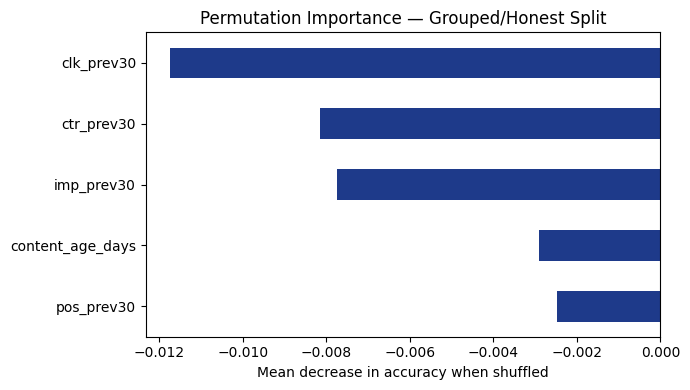

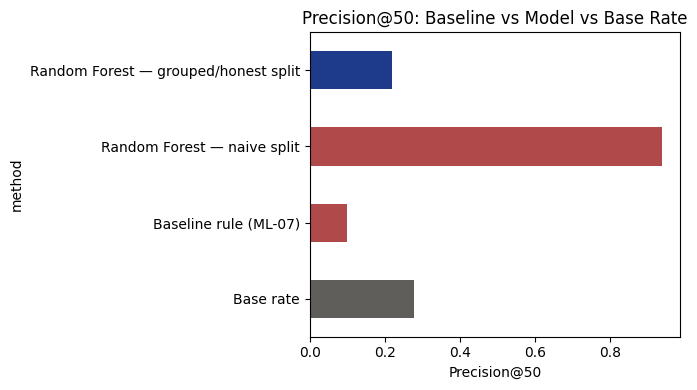

In [30]:
import matplotlib.pyplot as plt
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(7,4))
importance.plot(kind='barh', ax=ax, color='#1E3A8A')
ax.set_title("Permutation Importance — Grouped/Honest Split")
ax.set_xlabel("Mean decrease in accuracy when shuffled")
plt.tight_layout()
plt.savefig('work/figures/permutation_importance.png', dpi=150)

fig2, ax2 = plt.subplots(figsize=(7,4))
results.set_index('method')['precision_at_50'].plot(kind='barh', ax=ax2, color=['#5F5E5A','#B04A4A','#B04A4A','#1E3A8A'])
ax2.set_title("Precision@50: Baseline vs Model vs Base Rate")
ax2.set_xlabel("Precision@50")
plt.tight_layout()
plt.savefig('work/figures/precision_comparison.png', dpi=150)

results.to_json('work/outputs/results_metrics.json', orient='records', indent=2)
queue.head(50).to_csv('work/outputs/ranked_queue_top50.csv', index=False)
print("Artifacts saved to work/figures/ and work/outputs/")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.